In [1]:
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import rc, rcParams
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import pandas as pd
import numpy as np
from astropy.io import ascii
from astropy.time import Time
from astropy.table import Table

In [2]:
def flux_error(mag, err_mag):
    err_down = 10**(-0.4*(mag - err_mag)) - 10**(-0.4*mag)
    err_up = 10**(-0.4*mag) - 10**(-0.4*(mag + err_mag))
    err_flux = 0.5*(err_down + err_up)
    return err_flux

In [3]:
def mag_error(flux, err_flux):
    err_down = abs(-2.5*np.log10(flux + err_flux) + 2.5*np.log10(flux))
    err_up = abs(-2.5*np.log10(flux) + 2.5*np.log10(flux - err_flux))
    err_down = np.where(np.isnan(err_down), 1e4, err_down)
    err_up = np.where(np.isnan(err_up), 1e4, err_up)
    return err_down, err_up

In [69]:
# snad object:
# 533202300011210 19.608, 0.051  Почему на графике получаются другие значения звездных величин?
# 790209200005857  19.95, 0.069
# 676207400000993 20.729, 0.08
# 676212300024137 20.808, 0.048
# 787210100006486 21.665, 0.141
# 650202200001826 21.478, 0.074
# 759201400013865 21.003, 0.061
# 759209300030421 20.113, 0.063
oid = '759209300030421'
url = 'https://ztf.snad.space/latest/csv/' + oid
data = Table.from_pandas(pd.read_csv(url))
xlim = [58200,59000]
ylim = [18,24]


# from ztf refmag or the last photometrical point for this OID
ref, err_ref = 20.113, 0.063

data['flux'] = 10**(-0.4*data['mag']) - 10**(-0.4*ref)
data['fluxerr'] = np.sqrt(flux_error(data['mag'],data['magerr'])**2 + flux_error(ref,err_ref)**2)
data['magerr_down'] = mag_error(data['flux'], data['fluxerr'])[0]
data['magerr_up'] = mag_error(data['flux'], data['fluxerr'])[1]

/tmp/ipykernel_1719/704774284.py:2: RuntimeWarning: invalid value encountered in log10
  err_down = abs(-2.5*np.log10(flux + err_flux) + 2.5*np.log10(flux))
/tmp/ipykernel_1719/704774284.py:3: RuntimeWarning: invalid value encountered in log10
  err_up = abs(-2.5*np.log10(flux) + 2.5*np.log10(flux - err_flux))


/tmp/ipykernel_1719/283350568.py:26: RuntimeWarning: invalid value encountered in log10
  y=-2.5*np.log10(data['flux']),
/tmp/ipykernel_1719/704774284.py:2: RuntimeWarning: invalid value encountered in log10
  err_down = abs(-2.5*np.log10(flux + err_flux) + 2.5*np.log10(flux))
/tmp/ipykernel_1719/704774284.py:3: RuntimeWarning: invalid value encountered in log10
  err_up = abs(-2.5*np.log10(flux) + 2.5*np.log10(flux - err_flux))


First detection: t_UTC = 2018-04-11 10:37:30.144, mag = 21.07, magerr_down = 0.30, magerr_up = 0.42


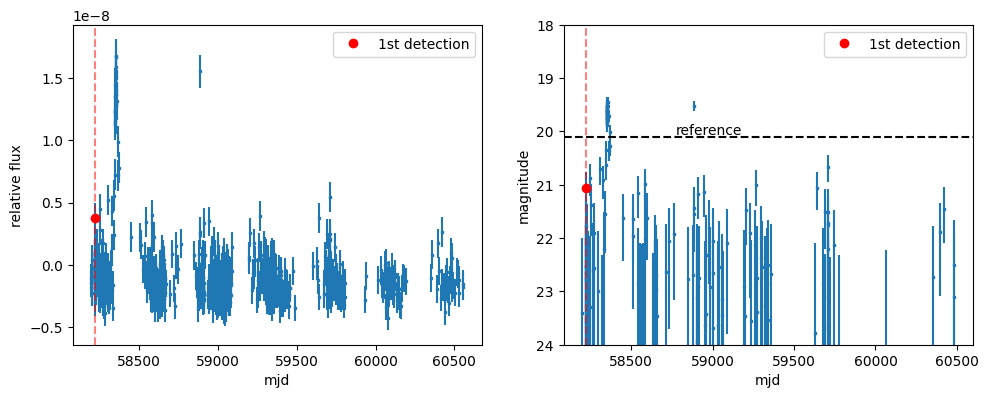

In [70]:
# the moment in time when the flux exceeded 3*sigma
for i in data:
    if i['flux'] > 3*i['fluxerr']:
        tr_time = i['mjd']
        flux = i['flux']
        mag = -2.5*np.log10(i['flux'])
        magerr_down = i['magerr_down']
        magerr_up = i['magerr_up']
        break
        
fig = plt.figure(figsize=(10,4))
fig.subplots_adjust(left=.08, bottom=.15, right=.98, top=0.95)
gs = GridSpec(1, 2, height_ratios=[1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

ax1.errorbar(x=data['mjd'],y=data['flux'],yerr=data['fluxerr'], marker='s', ms=2, mew=1, ls='none', zorder=-1)
ax1.axvline(x=tr_time, color='red', ls='--', zorder=0, alpha=0.5)
ax1.plot(tr_time, flux, 'ro', label='1st detection')
ax1.set_xlabel('mjd')
ax1.set_ylabel('relative flux')
ax1.legend()

ax2.errorbar(x=data['mjd'],
             y=-2.5*np.log10(data['flux']),
             yerr=(mag_error(data['flux'],
             data['fluxerr'])[0],
             mag_error(data['flux'],
             data['fluxerr'])[1]),
             marker='s',
             ms=2,
             mew=1,
             ls='none',
             zorder=-1)
ax2.axvline(x=tr_time, color='red', ls='--', zorder=0, alpha=0.5)
ax2.plot(tr_time, mag, 'ro', label='1st detection')
ax2.axhline(y=ref, color='black', ls='--', zorder=1)
#ax2.set_xlim(xlim)

# adding the label above the black horizontal line
ax2.text(x=data['mjd'].mean(), y=ref, s='reference', color='black', ha='center', va='bottom', fontsize=10, zorder=2)

ax2.set_ylim(ylim)
ax2.invert_yaxis()
ax2.set_xlabel('mjd')
ax2.set_ylabel('magnitude')
ax2.legend()

t_mjd = Time(tr_time, format='mjd', scale='utc')

print('First detection: t_UTC = %s, mag = %2.2f, magerr_down = %2.2f, magerr_up = %2.2f' %(t_mjd.iso, mag, magerr_down, magerr_up))

In [75]:
# Прямая ссылка на PNG
url = "https://ztf.snad.space/dr23/figure/790209200005857?other_oid=791212200005808&other_oid=790109200007782&other_oid=791312200006899&other_oid=790309200007735&other_oid=791112200010753&other_oid=1825203200004804&other_oid=1825103200003510&title=790209200005857&min_mjd=50000&max_mjd=70000&format=png"

# Название файла для сохранения
filename = f"OID_plots_to_add/{oid}.png"

# Скачивание
response = requests.get(url)
if response.ok:
    with open(filename, "wb") as f:
        f.write(response.content)
else:
    print(f"Error: {response.status_code}")